In [2]:
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
def quad(x,mu, a, b):
    return b*(x-mu)**2 + a

def gauss(x,mu, sig, A):
    return A*np.exp(-(x-mu)**2/(2*sig**2))

14.505395846037636
14.792125927627978
17.836223072812246
18.122953154402587


Text(2, 8, 'Important Point')

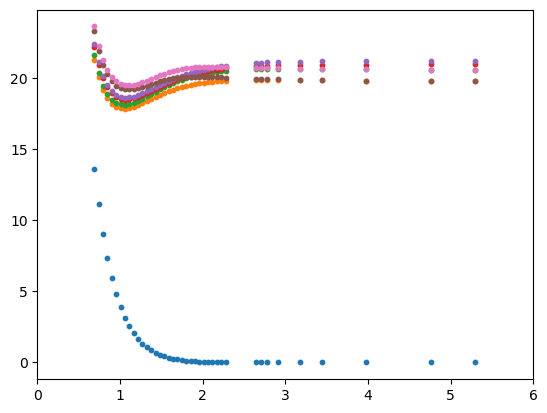

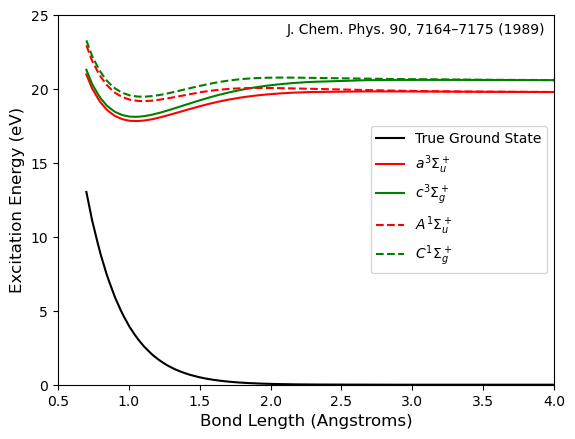

In [9]:
thing = np.array([[1.30, 109771.74, 27663.493, 30286.138, 35239.087, 36828.256, 43823.793, 46585.942],
                  [1.40, 89580.587, 17773.519, 20197.257, 24803.386, 26268.172, 32860.277, 35463.299],
                  [1.50, 72945.670, 10773.991, 13084.265, 17346.777, 18710.095, 24951.640, 27440.531],
                  [1.60, 59276.878, 5985.0441, 8238.3766, 12170.672, 13450.917, 19377.147, 21788.242],
                  [1.70, 48076.079, 2880.1684, 5115.3803, 8736.1362, 9948.3006, 15582.084, 17946.018],
                  [1.80, 38921.407, 1049.3464, 3294.3896, 6624.6223, 7781.1549, 13136.259, 15479.451],
                  [1.90, 31456.806, 172.56723, 2448.7079, 5510.1112, 6621.5515, 11704.598, 14050.663],
                  [2.00, 25383.382, 0.0000000, 2324.4058, 5138.4526, 6213.8964, 11025.470, 13396.424],
                  [2.10, 20451.539, 336.81786, 2724.1808, 5311.6733, 6359.1043, 10894.317, 13311.566],
                  [2.20, 16453.847, 1031.4438, 3495.0117, 5875.8786, 6902.4123, 11151.100, 13636.245],
                  [2.30, 13218.651, 1966.3893, 4518.6198, 6711.8585, 7723.9245, 11670.604, 14246.087],
                  [2.40, 10604.464, 3051.0782, 5704.0430, 7727.7511, 8731.2273, 12354.902, 15044.499],
                  [2.50, 8495.0774, 4216.1792, 6981.7816, 8853.2565, 9853.5661, 13127.496, 15956.592],
                  [2.60, 6825.8433, 5422.3910, 8303.2544, 10008.327, 11021.873, 13943.729, 16949.471],
                  [2.70, 5457.9883, 6605.5529, 9621.7295, 11200.725, 12221.784, 14730.803, 17931.676],
                  [2.80, 4358.1148, 7747.6319, 10910.780, 12378.772, 13412.032, 15465.078, 18889.292],
                  [2.90, 3475.0523, 8827.9113, 12148.695, 13520.760, 14570.476, 16121.322, 19794.934],
                  [3.00, 2767.0177, 9832.0670, 13319.702, 14611.306, 15681.350, 16683.176, 20626.900],
                  [3.10, 2200.0549, 10751.074, 14412.792, 15639.992, 16733.844, 17142.742, 21368.436],
                  [3.20, 1746.6316, 11580.346, 15420.965, 16600.333, 17721.067, 17499.849, 22007.612],
                  [3.30, 1384.4643, 12319.029, 16340.735, 17488.971, 18639.235, 17760.731, 22537.782],
                  [3.40, 1095.5466, 12969.290, 17171.639, 18305.015, 19487.015, 17936.175, 22958.198],
                  [3.50, 865.34953, 13535.579, 17915.670, 19049.472, 20264.967, 18039.434, 23274.178],
                  [3.60, 682.16792, 14023.893, 18576.666, 19724.758, 20975.057, 18084.338, 23496.357],
                  [3.70, 536.58674, 14441.129, 19159.737, 20334.278, 21620.254, 18083.884, 23638.981],
                  [3.80, 421.04431, 14794.554, 19670.786, 20882.077, 22204.183, 18049.412, 23717.748],
                  [3.90, 329.47658, 15091.406, 20116.115, 21372.562, 22730.865, 17990.293, 23747.828],
                  [4.00, 257.02639, 15338.623, 20502.140, 21810.285, 23204.503, 17913.955, 23742.541],
                  [4.10, 199.80699, 15542.662, 20835.156, 22199.788, 23629.329, 17826.109, 23712.763],
                  [4.20, 154.71043, 15709.408, 21121.179, 22545.489, 24009.500, 17731.053, 23666.896],
                  [4.30, 119.25259, 15844.130, 21365.829, 22851.610, 24349.021, 17631.961, 23611.150],
                  [5.00, 15.760877, 16215.817, 22290.832, 24185.132, 25877.032, 16957.622, 23182.243],
                  [5.10, 11.251343, 16220.119, 22349.552, 24294.436, 26008.144, 16872.747, 23127.910],
                  [5.25, 6.5112372, 16214.646, 22416.576, 24433.359, 26177.147, 16752.499, 23050.833],
                  [5.50, 2.1899315, 16183.258, 22484.027, 24611.009, 26398.452, 16571.398, 22933.267],
                  [6.00, 0.0000000, 16081.612, 22510.910, 24828.766, 26683.213, 16280.491, 22732.631],
                  [6.50, 0.70318255, 15977.213, 22464.610, 24940.631, 26841.946, 16076.825, 22571.156],
                  [7.50, 3.3074513, 15851.251, 22334.814, 25031.012, 26989.996, 15874.830, 22357.150],
                  [9.00, 4.9099904, 15773.995, 22198.465, 25066.295, 27067.567, 15776.393, 22200.248],
                  [10.00, 5.2143963, 15752.358, 22153.784, 25074.124, 27090.215, 15752.846, 22154.629 ],
                  [40.00, 5.9767204, 15751.860, 22128.165, 25085.431, 27138.261, 15751.860, 22130.065]])
cm_ev = 0.0001239843
thing[:,0] = thing[:,0] * 0.529177
thing[:, 1:] = thing[:, 1:] * cm_ev
thing[:, 1] = thing[:, 1] 
thing[:, 2:] = thing[:, 2:] -140.0566081 + 157.887612

fig, ax = plt.subplots()

ax.scatter(thing[:,0],thing[:,1], s = 10)
ax.scatter(thing[:,0],thing[:,2], s = 10)
ax.scatter(thing[:,0],thing[:,3], s = 10)
ax.scatter(thing[:,0],thing[:,4], s = 10)
ax.scatter(thing[:,0],thing[:,5], s = 10)
ax.scatter(thing[:,0],thing[:,6], s = 10)
ax.scatter(thing[:,0],thing[:,7], s = 10)

ax.set_xlim(0,6)

i = np.argmin(thing[:,2])
j = np.argmin(thing[:,3])




fX = interp1d(thing[:,0],thing[:,1], bounds_error = False)
fa = interp1d(thing[:,0],thing[:,2], bounds_error = False)
fA = interp1d(thing[:,0],thing[:,3], bounds_error = False)
fb = interp1d(thing[:,0],thing[:,4], bounds_error = False)
fB = interp1d(thing[:,0],thing[:,5], bounds_error = False)
fc = interp1d(thing[:,0],thing[:,6], bounds_error = False)
fC = interp1d(thing[:,0],thing[:,7], bounds_error = False)

fig, ax = plt.subplots()
tdata = np.linspace(.7, 21, 1000)

triplet_rad_min = tdata[np.argmin(fa(tdata))]
singlet_rad_min = tdata[np.argmin(fA(tdata))]

print(fa(triplet_rad_min) - fX(triplet_rad_min))
print(fA(singlet_rad_min) - fX(singlet_rad_min))
print(fa(triplet_rad_min))
print(fA(singlet_rad_min))



# ax.plot(tdata, fX(tdata), color = 'k', label = 'True Ground State')
# ax.plot(tdata, fa(tdata), color = 'r', label = 'Triplet w/ Vibrational Ground State')
# ax.plot(tdata, fA(tdata), color = 'g', label = 'Singlet w/ Vibrational Ground State')
# ax.plot(tdata, fc(tdata), color = 'r', ls = '--', label = 'Triplet w/ First Vibrational Quantum')
# ax.plot(tdata, fC(tdata), color = 'g', ls = '--', label = 'Singlet w/ First Vibrational Quantum')

ax.plot(tdata, fX(tdata), color = 'k', label = 'True Ground State')
ax.plot(tdata, fa(tdata), color = 'r', label = '$a^3\Sigma_u^+$')
ax.plot(tdata, fA(tdata), color = 'g', label = '$c^3\Sigma_g^+$')
ax.plot(tdata, fc(tdata), color = 'r', ls = '--', label = '$A^1\Sigma_u^+$')
ax.plot(tdata, fC(tdata), color = 'g', ls = '--', label = '$C^1\Sigma_g^+$')


# ax.plot([triplet_rad_min,triplet_rad_min],[fa(triplet_rad_min), fX(triplet_rad_min)], color = 'grey', marker = '.')
# ax.plot([singlet_rad_min,singlet_rad_min],[fA(singlet_rad_min), fX(singlet_rad_min)], color = 'grey', marker = '.')

ax.set_xlim(.5,4)
ax.text(.46,.95, 'J. Chem. Phys. 90, 7164–7175 (1989)', transform = ax.transAxes)
# ax.set_ylim(15,20)
ax.set_ylim(0,25)

# ax.set_ylim(0,6)

ax.legend(loc = 'right')
ax.set_xlabel('Bond Length (Angstroms)', fontsize = 12)
ax.set_ylabel('Excitation Energy (eV)', fontsize = 12)

ax.annotate('Important Point', # Optional text
            xy=(5, 5),          # Coordinates of the arrowhead
            xytext=(2, 8),      # Coordinates of the arrow tail
            arrowprops=dict(facecolor='black', shrink=0.05),
            )



0.21971440007280862
1.7286991556017632e-11
0.2228476384600349
1.7165033783321166e-11
0.22711329113877846
1.7003072445022926e-11
0.22874786745003867
1.6942213631101842e-11
0.19187116682557234
1.8498811298559826e-11
0.19705397127966082
1.825391755754158e-11


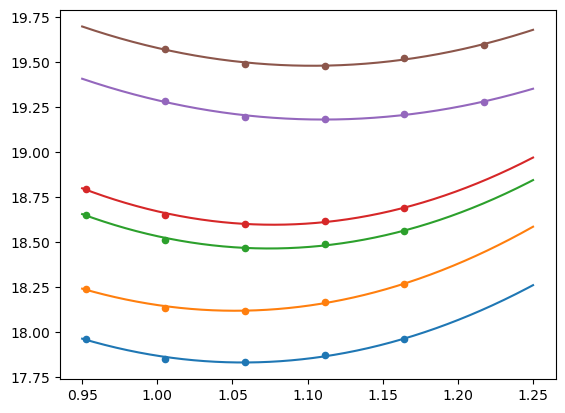

In [4]:
e = 1.602E-19
m = 6.6422E-27
hbar = 6.582E-16
hbar_SI = 6.626E-34
fig, ax = plt.subplots()
tdata = np.linspace(.95, 1.25, 1000)

ax.scatter(thing[5:10,0],thing[5:10,2], s = 20)
opt, cov = curve_fit(quad, thing[5:10,0],thing[5:10,2], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C0')

ax.scatter(thing[5:10,0],thing[5:10,3], s = 20)
opt, cov = curve_fit(quad, thing[5:10,0],thing[5:10,3], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C1')

ax.scatter(thing[5:10,0],thing[5:10,4], s = 20)
opt, cov = curve_fit(quad, thing[5:10,0],thing[5:10,4], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C2')

ax.scatter(thing[5:10,0],thing[5:10,5], s = 20)
opt, cov = curve_fit(quad, thing[5:10,0],thing[5:10,5], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C3')

ax.scatter(thing[6:11,0],thing[6:11,6], s = 20)
opt, cov = curve_fit(quad, thing[6:11,0],thing[6:11,6], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C4')

ax.scatter(thing[6:11,0],thing[6:11,7], s = 20)
opt, cov = curve_fit(quad, thing[6:11,0],thing[6:11,7], p0 = [1.05, 17.8, 1])
k = opt[2]*2 * e * 1e20
omega = np.sqrt(2*k/m)
print(hbar*omega)
print(np.sqrt(hbar_SI/(m * omega)))
ax.plot(tdata, quad(tdata, *opt), color = 'C5')

## Hopfield Continuum Width measurement

[18.29380093 17.42085792 16.93828367 16.55170256 15.97375699 15.6860618
 15.13697009 14.70645689 14.46122291 14.15366402 13.82296157 13.38508149
 13.12929427 12.73595607 12.22038764 11.73149929]
[15.27757507  1.14372562  0.80247791]


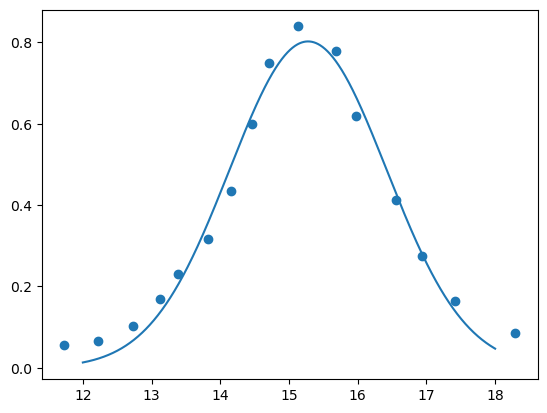

In [5]:
wav = np.array([67.89185062663019, 71.2938482091736, 73.32502067561549, 75.03759781156562, 77.7525287868185, 79.17857370061708, 82.05076658820536, 84.45270055347032, 85.88485272600037, 87.75112920669254, 89.85049939563585, 92.78987212927031, 94.59762071378586, 97.51918060945351, 101.6334372415548, 105.86882117183026])
int = np.array([0.08528958979382886, 0.16552618204049763, 0.2738194326794882, 0.4117898365509977, 0.6188890771281885, 0.7783163058610352, 0.8392100824242602, 0.7493462776496932, 0.5988391364235679, 0.43473457031106133, 0.31687303422927054, 0.2313256384381376, 0.16864195166505844, 0.10240790801482016, 0.06493028189244333, 0.05542828942037846])
h = 4.14e-15
c = 3e8

energy = h*(c/(wav*1e-9))
print(energy)
fig, ax = plt.subplots()

ax.scatter(energy, int)
tdata = np.linspace(12,18, 1000)
opt, cov = curve_fit(gauss, energy, int, p0 = [15, 1, 1])

ax.plot(tdata, gauss(tdata, *opt))
print(opt)


14.505395846037636


(11.403384204026901, 18.621916010138943)

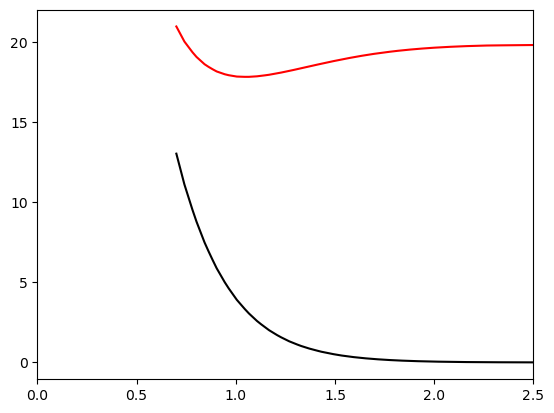

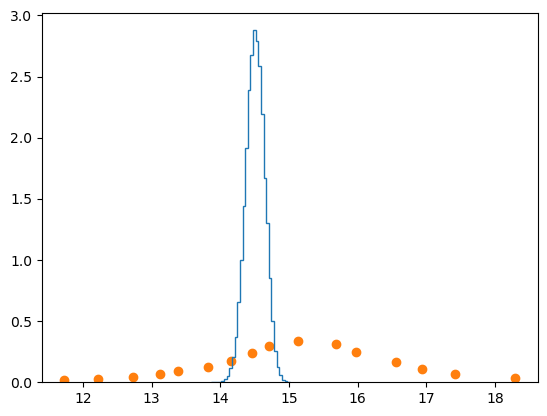

In [6]:
fig, ax = plt.subplots()
tdata = np.linspace(.7, 21, 1000)


triplet_rad_min = tdata[np.argmin(fa(tdata))]

print(fa(triplet_rad_min) - fX(triplet_rad_min))


ax.plot(tdata, fX(tdata), color = 'k', label = 'True Ground State')
ax.plot(tdata, fa(tdata), color = 'r', label = 'Triplet Ground State')

ax.set_xlim(0,2.5)

rads = np.random.normal(loc = triplet_rad_min, scale = .01, size = 100000)

fig, ax = plt.subplots()

ax.hist(fa(rads) - fX(rads), bins = 30, density=True, histtype = 'step')

ax.scatter(energy, .4*int)
ax.set_xlim()